<div class="alert alert-block alert-success">
<b>NOTEBOOK 4 - Clustering
</div>

---
# 1 - IMPORTS

### 1.1 - SETUP PROJECT

Make sure to check `README.md` and `requirements.txt` before running any notebooks. 

In [1]:
# Import modules
import sys
import importlib
import pandas as pd
from pathlib import Path


import warnings, os
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# --- Metrics + Model Selection Utilities (documented) ---

from __future__ import annotations
import numpy as np
import pandas as pd
from typing import Iterable, List, Tuple
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)


import matplotlib.pyplot as plt

### 1.2 - DEFINE PATHS

In [2]:
# Paths
PROJECT_PATH = Path.cwd().resolve().parent
DATA_PATH = PROJECT_PATH / "data"
SRC_PATH = PROJECT_PATH / "src"
UTILS_PATH = SRC_PATH / "utilities"
PROCESSED_PATH = DATA_PATH / "processed"
OUTPUT_PATH = PROJECT_PATH / "outputs"
FIG_PATH = OUTPUT_PATH / "figures"
OUT_PATH = PROCESSED_PATH

FIG_PATH.mkdir(parents=True, exist_ok=True)

# Add src to sys.path (for package-style imports)
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

# Add utilities folder to sys.path (for direct import utils)
if str(UTILS_PATH) not in sys.path:
    sys.path.append(str(UTILS_PATH))

# Import with reload
try:
    import utilities.utils as utils
except ModuleNotFoundError:
    import utils

reimport = importlib.reload(utils)

### 1.3 - LOAD DATASET

In [3]:
# Load Data

# Clustering data

# Original Dataset (scaled)
full_scaled_path = PROCESSED_PATH / "01_climate_dataset_scaled.xlsx"
full_scaled = pd.read_excel(full_scaled_path, sheet_name=None)["Sheet1"]

# Imputed Dataset (scaled, no outliers)
noout_scaled_path = PROCESSED_PATH / "01_climate_dataset_scaled_noOutliers.xlsx"
noout_scaled = pd.read_excel(noout_scaled_path, sheet_name=None)["Sheet1"]

# PCA 90% Var Scaled Original
PCA_90Var_scaled_original_path = PROCESSED_PATH / "02_climate_dataset_PCA_90Var.xlsx"
pca90_full = pd.read_excel(PCA_90Var_scaled_original_path, sheet_name=None)["Sheet1"]

# PCA 90% Var Scaled Imputed
PCA_90Var_scaled_imputed_path = PROCESSED_PATH / "02_climate_dataset_PCA_90Var_noOutliers.xlsx"
pca90_noout = pd.read_excel(PCA_90Var_scaled_imputed_path, sheet_name=None)["Sheet1"]

# PCA 2D Scaled Original
PCA_2D_scaled_original_path = PROCESSED_PATH / "02_climate_dataset_PCA_2D.xlsx"
pca2d_full = pd.read_excel(PCA_2D_scaled_original_path, sheet_name=None)["Sheet1"]

# PCA 2D Scaled Imputed
PCA_2D_scaled_imputed_path = PROCESSED_PATH / "02_climate_dataset_PCA_2D_noOutliers.xlsx"
pca2d_noout  = pd.read_excel(PCA_2D_scaled_imputed_path, sheet_name=None)["Sheet1"]

# t-SNE 2D Scaled Original
tSNE_2D_scaled_original_path = PROCESSED_PATH / "02_climate_dataset_tSNE_2D.xlsx"
tsne2d_full = pd.read_excel(tSNE_2D_scaled_original_path, sheet_name=None)["Sheet1"]

# t-SNE 2D Scaled Imputed
tSNE_2D_scaled_imputed_path = PROCESSED_PATH / "02_climate_dataset_tSNE_2D_noOutliers.xlsx"
tsne2d_noout = pd.read_excel(tSNE_2D_scaled_imputed_path, sheet_name=None)["Sheet1"]

# UMAP 2D Scaled Original
UMAP_2D_scaled_original_path = PROCESSED_PATH / "02_climate_dataset_UMAP_2D.xlsx"
umap2d_full = pd.read_excel(UMAP_2D_scaled_original_path, sheet_name=None)["Sheet1"]

# UMAP 2D Scaled Imputed
UMAP_2D_scaled_imputed_path = PROCESSED_PATH / "02_climate_dataset_UMAP_2D_noOutliers.xlsx"
umap2d_noout = pd.read_excel(UMAP_2D_scaled_imputed_path, sheet_name=None)["Sheet1"]

# Descriptive Stats Original
descriptive_original_df = PROCESSED_PATH / "01_climate_dataset_descriptive_features.xlsx"
desc_full = pd.read_excel(descriptive_original_df, sheet_name=None)["Sheet1"]

# Descriptive Stats Imputed
descriptive_imputed_df = PROCESSED_PATH / "01_climate_dataset_descriptive_features_noOutliers.xlsx"
desc_noout = pd.read_excel(descriptive_imputed_df, sheet_name=None)["Sheet1"]

# Create a row_id as merge key if you don't have an explicit ID
for df in [pca90_full, pca90_noout, pca2d_full, pca2d_noout, tsne2d_full, tsne2d_noout, umap2d_full, umap2d_noout, desc_full, desc_noout]:
    if "row_id" not in df.columns:
        df.insert(0, "row_id", np.arange(len(df)))
        
# Convenience containers
DATASETS = {
    "full": {
        "pca90":  pca90_full.copy(),
        "pca2d":  pca2d_full.copy(),
        "tsne2d": tsne2d_full.copy(),
        "umap2d": umap2d_full.copy(),
        "desc":   desc_full.copy(),
    },
    "no_outliers": {
        "pca90":  pca90_noout.copy(),
        "pca2d":  pca2d_noout.copy(),
        "tsne2d": tsne2d_noout.copy(),
        "umap2d": umap2d_noout.copy(),
        "desc":   desc_noout.copy(),
    }
}

# Identify numeric columns for clustering
def numeric_cols(df):
    return df.select_dtypes(include=[np.number]).columns.tolist()

Xcols_full   = [c for c in numeric_cols(pca90_full) if c != "row_id"]
Xcols_noout  = [c for c in numeric_cols(pca90_noout) if c != "row_id"]

print(len(pca90_full), len(pca90_noout), len(Xcols_full), len(Xcols_noout))

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

1008 957 9 9


---
# 2 - CLUSTERING

### 2.1 - CORE CLUSTERING (K-MEANS & AGGLO)

This section contains the helper functions that handle **model evaluation, comparison, and selection** for clustering.  
They compute internal metrics, test multiple algorithms and cluster counts, normalize results for comparison, and identify the most promising configuration.

The logic is built to stay transparent — every choice can be traced and explained in a report.

`eval_metrics(X, labels)`

**What it does**
This function calculates three **internal validation metrics** that assess how well a clustering partitions the data, *without needing ground truth labels*.

**Metrics**
| Metric | Interpretation | Direction | Description |
|:--|:--|:--|:--|
| **Silhouette Score** | Higher means better separation between clusters | ↑ | Compares average distance to points in same cluster vs points in the nearest other cluster. |
| **Calinski–Harabasz (CH) Index** | Higher means more compact and well-separated clusters | ↑ | Ratio of between-cluster variance to within-cluster variance. |
| **Davies–Bouldin (DB) Index** | Lower means better clustering (less overlap) | ↓ | Measures average similarity between each cluster and its most similar one. |

**How it works**
- It first checks for trivial cases (fewer than 2 clusters, or as many clusters as data points).  
  In such cases, metrics don’t make sense, so it returns `NaN`s.
- Otherwise, it safely computes the three metrics using scikit-learn functions.
- If any metric fails due to a numerical issue, it gets replaced with `NaN`.

**Inputs**
- `X`: data matrix used for clustering (should be scaled or PCA-reduced).  
- `labels`: cluster assignments for each sample.

**Output**
A tuple of three numbers: `(silhouette, calinski_harabasz, davies_bouldin)`.

**Why it matters**
These metrics describe clustering quality from different angles:
- *Silhouette* → shape and isolation of clusters.  
- *CH* → ratio of between vs within dispersion.  
- *DB* → average overlap or similarity between clusters.  
Looking at all three reduces bias from any one measure.

In [4]:
def eval_metrics(X: np.ndarray | pd.DataFrame, labels: np.ndarray | pd.Series) -> Tuple[float, float, float]:
    """
    Compute standard internal clustering validity metrics with safe guards.

    Returns a tuple: (silhouette, calinski_harabasz, davies_bouldin).
    If the clustering is trivial (fewer than 2 clusters or as many clusters as points),
    or if a metric fails numerically, the corresponding value is np.nan.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        The feature matrix used for clustering (ideally scaled).
    labels : array-like of shape (n_samples,)
        Cluster labels produced by a clustering algorithm.

    Notes
    -----
    - Silhouette: higher is better; requires at least 2 clusters.
    - Calinski–Harabasz (CH): higher is better.
    - Davies–Bouldin (DB): lower is better.
    """
    X = np.asarray(X)
    labels = np.asarray(labels)

    n_unique = np.unique(labels).size
    if n_unique < 2 or n_unique >= len(labels):
        return (np.nan, np.nan, np.nan)

    def _safe(fn):
        try:
            return float(fn(X, labels))
        except Exception:
            return np.nan

    sil = _safe(silhouette_score)
    ch  = _safe(calinski_harabasz_score)
    db  = _safe(davies_bouldin_score)
    return (sil, ch, db)

`evaluate_kmeans(X, k_values, n_init=20, random_state=None)`
**Purpose.** Run **K-Means** for each `k` in `k_values` and record metrics.

**Inputs.**
- `X` — feature matrix.
- `k_values` — iterable of candidate cluster counts (e.g., `range(2, 11)`).
- `n_init` — how many centroid restarts (higher → more stable).
- `random_state` — for reproducibility.

**Outputs.**
- A DataFrame with one row per `(algo='kmeans', k)`, including `silhouette`, `calinski_harabasz`, `davies_bouldin`.

**Why it matters.** K-Means is a fast, interpretable baseline; sweeping `k` gives the shape of the “elbow/peaks” in metrics.

In [5]:
def evaluate_kmeans(
    X: np.ndarray | pd.DataFrame,
    k_values: Iterable[int],
    n_init: int = 20,
    random_state: int | None = None,
) -> pd.DataFrame:
    """
    Grid-evaluate K-Means over a list/range of k and collect validity metrics.

    Parameters
    ----------
    X : array-like, (n_samples, n_features)
        Feature matrix (preferably PCA-reduced & scaled).
    k_values : iterable of int
        Candidate numbers of clusters to test (e.g., range(2, 11)).
    n_init : int, default=20
        Number of centroid seeds; higher -> more stable results.
    random_state : int or None
        Controls centroid initialization reproducibility.

    Returns
    -------
    pd.DataFrame
        Columns: ['algo','k','silhouette','calinski_harabasz','davies_bouldin'].
    """
    X = np.asarray(X)
    rows: List[dict] = []

    for k in k_values:
        model = KMeans(n_clusters=k, n_init=n_init, random_state=random_state)
        labels = model.fit_predict(X)
        sil, ch, db = eval_metrics(X, labels)
        rows.append({
            "algo": "kmeans",
            "k": int(k),
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db,
        })

    return pd.DataFrame(rows)

`evaluate_agglo(X, k_values, linkage='ward')`
**Purpose.** Run **Agglomerative (hierarchical)** clustering for each `k` and record metrics.

**Inputs.**
- `X` — feature matrix.
- `k_values` — candidate cluster counts.
- `linkage` — how clusters are merged (`'ward'`, `'average'`, `'complete'`, `'single'`).  
  - `'ward'` assumes Euclidean geometry and favors compact, spherical clusters.

**Outputs.**
- A DataFrame with one row per `(algo=f'agglo-{linkage}', k)` and the same three metrics.

**Why it matters.** Hierarchical clustering can reveal nested structure and often behaves differently from K-Means; comparing both improves robustness.

In [6]:
def evaluate_agglo(
    X: np.ndarray | pd.DataFrame,
    k_values: Iterable[int],
    linkage: str = "ward",
) -> pd.DataFrame:
    """
    Grid-evaluate Agglomerative (hierarchical) clustering over k and collect metrics.

    Parameters
    ----------
    X : array-like, (n_samples, n_features)
        Feature matrix (preferably PCA-reduced & scaled).
    k_values : iterable of int
        Candidate numbers of clusters to test (e.g., range(2, 11)).
    linkage : {'ward','average','complete','single'}, default='ward'
        Linkage criterion. 'ward' assumes Euclidean and tends to compact, spherical clusters.

    Returns
    -------
    pd.DataFrame
        Columns: ['algo','k','silhouette','calinski_harabasz','davies_bouldin'].
    """
    X = np.asarray(X)
    rows: List[dict] = []

    for k in k_values:
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = model.fit_predict(X)
        sil, ch, db = eval_metrics(X, labels)
        rows.append({
            "algo": f"agglo-{linkage}",
            "k": int(k),
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db,
        })

    return pd.DataFrame(rows)

`normalize_columns(df, cols, invert=None)`
**Purpose.** Put different metric scales onto a common `[0, 1]` footing so they can be combined.

**How.**
- Column-wise **min–max** normalization for each metric in `cols`.
- If a metric is *lower-is-better* (e.g., Davies–Bouldin), list it in `invert` to flip its direction (`1 - norm`).
- Constant columns become `0.5` (neutral) to avoid biasing the composite.

**Inputs.**
- `df` — table of metric values.
- `cols` — which columns to normalize.
- `invert` — list of columns to flip because lower is better.

**Outputs.**
- A copy of `df` with additional `{col}_norm` columns.

**Why it matters.** Mixed-scale metrics can’t be averaged meaningfully until they’re normalized and aligned in direction.

In [7]:
def normalize_columns(
    df: pd.DataFrame,
    cols: List[str],
    invert: List[str] | None = None,
) -> pd.DataFrame:
    """
    Min–max normalize specified metric columns to [0, 1] (column-wise), with optional inversion.

    Parameters
    ----------
    df : pd.DataFrame
        Input table (e.g., model-by-k scores).
    cols : list of str
        Column names to normalize.
    invert : list of str or None
        Columns where lower-is-better (e.g., 'davies_bouldin').
        These will be flipped as: norm -> 1 - norm.

    Returns
    -------
    pd.DataFrame
        Copy of df with additional '{col}_norm' columns.
    """
    out = df.copy()
    invert = invert or []

    for c in cols:
        values = pd.to_numeric(out[c], errors="coerce").to_numpy()
        finite_mask = np.isfinite(values)

        # Default all to NaN
        out[c + "_norm"] = np.nan

        if finite_mask.any():
            vmin = float(np.nanmin(values[finite_mask]))
            vmax = float(np.nanmax(values[finite_mask]))
            if vmax > vmin:
                out.loc[finite_mask, c + "_norm"] = (values[finite_mask] - vmin) / (vmax - vmin)
            else:
                # constant column -> neutral 0.5
                out.loc[finite_mask, c + "_norm"] = 0.5

        if c in invert:
            out[c + "_norm"] = 1.0 - out[c + "_norm"]

    return out

`pick_best_row(scores_df)`
**Purpose.** Pick the “best” (algorithm, k) by a simple, transparent composite.

**Composite definition.**
\[
\text{composite} = \text{mean}\big( \text{silhouette\_norm},\ \text{calinski\_harabasz\_norm},\ \text{davies\_bouldin\_norm} \big)
\]
where **Davies–Bouldin is inverted** during normalization so that “higher is better” for all terms.

**Inputs.**
- `scores_df` — must contain raw `silhouette`, `calinski_harabasz`, and `davies_bouldin` columns (from `evaluate_*`).

**Outputs.**
- `best_row` — the single highest-composite configuration (as a Series).
- `scored_df` — the full table augmented with normalized columns and the `composite` score.

**Why it matters.** A simple average reduces overfitting to any one metric and stays easy to explain in your report.


In [8]:
def pick_best_row(scores_df: pd.DataFrame) -> Tuple[pd.Series, pd.DataFrame]:
    """
    Pick the best (algo, k) row via a simple composite of normalized metrics.

    Composite = mean of:
        - silhouette_norm (higher better)
        - calinski_harabasz_norm (higher better)
        - davies_bouldin_norm (lower better -> inverted)

    Parameters
    ----------
    scores_df : pd.DataFrame
        Must contain raw columns: 'silhouette', 'calinski_harabasz', 'davies_bouldin'.

    Returns
    -------
    best_row : pd.Series
        The single best configuration (highest composite).
    scored_df : pd.DataFrame
        scores_df augmented with *_norm columns and 'composite'.
    """
    needed = {"silhouette", "calinski_harabasz", "davies_bouldin"}
    missing = needed - set(scores_df.columns)
    if missing:
        raise ValueError(f"Missing required metric columns: {sorted(missing)}")

    s = normalize_columns(
        scores_df,
        ["silhouette", "calinski_harabasz", "davies_bouldin"],
        invert=["davies_bouldin"],
    )
    s["composite"] = s[[
        "silhouette_norm",
        "calinski_harabasz_norm",
        "davies_bouldin_norm",
    ]].mean(axis=1)

    best_row = s.sort_values("composite", ascending=False).iloc[0]
    return best_row, s

**Practical notes**
- **Use PCA-90% space for clustering.** Distance-based algorithms behave better in denoised, scaled spaces.
- **Sweep multiple algorithms.** If K-Means and Agglomerative agree on the same `k`, confidence goes up.
- **Treat `NaN`s as “not decisive.”** If metrics are `NaN` for some `(algo, k)`, they won’t dominate the composite.
- **You can still overrule.** If the chosen `k` looks messy on PCA-2D/t-SNE, it’s valid to pick the next-best that’s visually cleaner—just note it in the write-up.

Here's the usage of the functions above. 
>1. I started off by defining the `k` search space;
>2. I then ran the same evaluation twice on full and no_outliers datasets (both clustered in 90 var PCA space, which was previously scaled and denoised).
>3. I evaluated two algorithms across all `k`s. Fo each `k` I fit **K-Means** (centroid based, spherical clusters, fast, stable) and **Agglomerative (Ward)** (hierarchical, compact clusters; can capture nested structure).
>4. I collected three internal metrics per algorithm: Silhouette (↑ better separation),Calinski–Harabasz (↑ compact & separated) and Davies–Bouldin (↓ less overlap).
>5. I picked the best configuration via a composite score (`pick_best_row()`) which ormalizes each metric to 0–1 (and inverts DB so higher=better for all), averages them into a composite score and returns the top row: (algorithm, k) with the highest composite. Why composite? Each metric sees “quality” differently. Averaging normalized metrics tends to choose stable, non-pathological solutions.
>6. I plotted the metric curves for a quick visual read. You get three line plots per dataset (full / no_outliers), each showing the metric vs k, with separate lines for K-Means and Agglomerative.
>7. Finally, I returned the two "winners": `results["full"]["best"]` → best (algo, k) on all data, and `results["no_outliers"]["best"]` → best (algo, k) after outlier removal.

**How to interpret the plots**
>- Silhouette: look for peaks. A sharp local max often marks a natural k.
>- Calinski–Harabasz: tends to increase with better separation; watch for elbows rather than raw magnitude.
>- Davies–Bouldin: lower is better; look for dips or flattening.

Files are saved to /figures for your report.

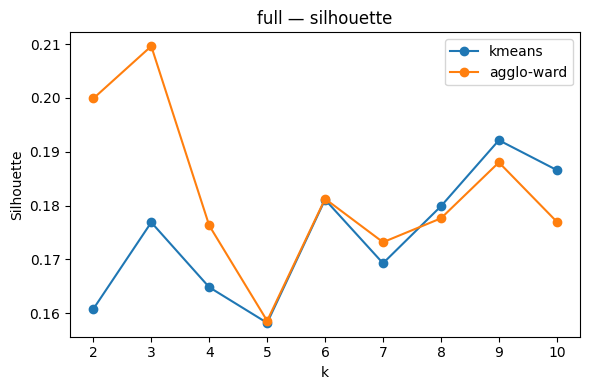

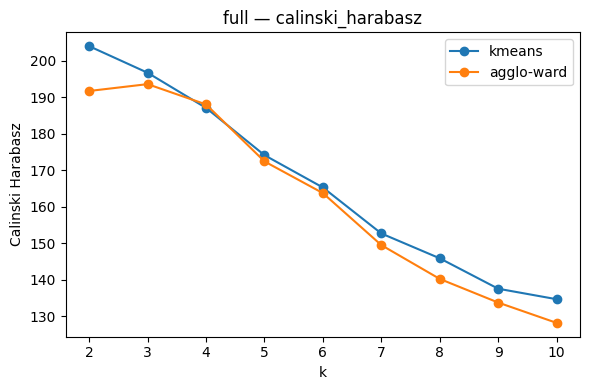

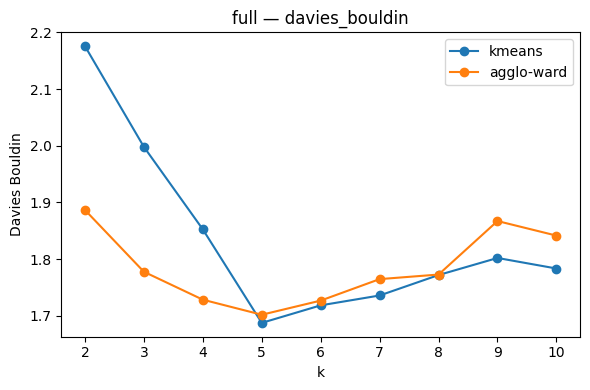

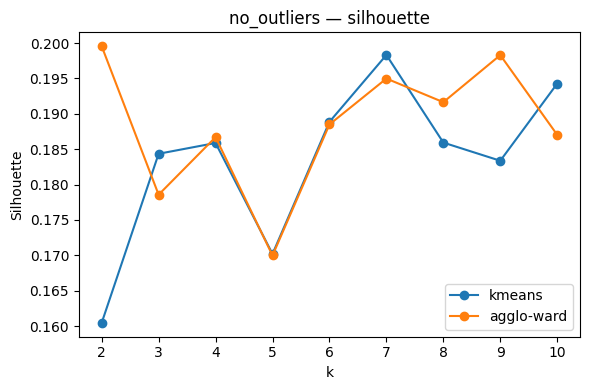

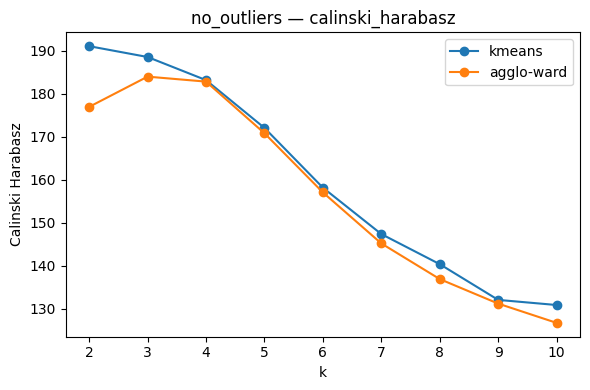

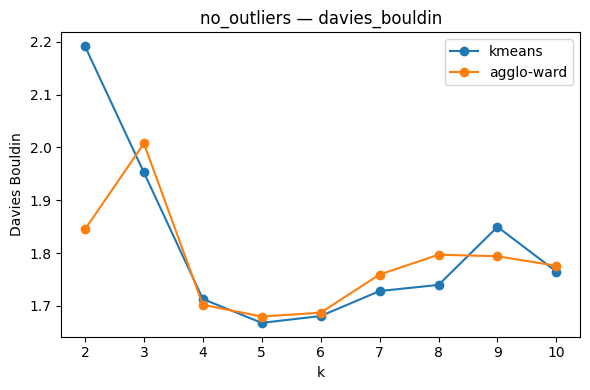

(algo                      agglo-ward
 k                                  3
 silhouette                  0.209632
 calinski_harabasz         193.647006
 davies_bouldin              1.777636
 silhouette_norm                  1.0
 calinski_harabasz_norm      0.862801
 davies_bouldin_norm         0.815295
 composite                   0.892699
 Name: 10, dtype: object,
 algo                      agglo-ward
 k                                  4
 silhouette                  0.186699
 calinski_harabasz         182.806737
 davies_bouldin              1.701993
 silhouette_norm             0.671275
 calinski_harabasz_norm      0.871885
 davies_bouldin_norm         0.934611
 composite                   0.825924
 Name: 11, dtype: object)

In [9]:
k_values = range(2, 11)

results = {}
for label, bundle in DATASETS.items():
    X = bundle["pca90"][Xcols_full if label=="full" else Xcols_noout].values
    df_km   = evaluate_kmeans(X, k_values)
    df_ag   = evaluate_agglo(X, k_values, linkage="ward")
    scores  = pd.concat([df_km, df_ag], ignore_index=True)
    best, scored = pick_best_row(scores)
    results[label] = {"scores": scored, "best": best}

    # Quick plot
    for metric in ["silhouette", "calinski_harabasz", "davies_bouldin"]:
        plt.figure(figsize=(6,4))
        for algo in scored["algo"].unique():
            sub = scored[scored["algo"]==algo]
            plt.plot(sub["k"], sub[metric], marker="o", label=algo)
        plt.xlabel("k"); plt.ylabel(metric.replace("_"," ").title()); plt.title(f"{label} — {metric}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(FIG_PATH / f"{label}_{metric}.png", dpi=140)
        plt.show()

results["full"]["best"], results["no_outliers"]["best"]


**Intepretation**

**Step 1 — Quantitative summary**
From the metric tables:

| Dataset | Algorithm | k | Silhouette | CH Index | DB Index | Composite |
|:--|:--|--:|--:|--:|--:|--:|
| **Full (scaled PCA-90%)** | Agglomerative (Ward) | **3** | **0.21** | 193.6 | 1.78 | **0.89** |
| Full | Agglomerative (Ward) | 4 | 0.19 | 182.8 | 1.70 | 0.83 |

The **composite score** (mean of normalized Silhouette ↑, Calinski–Harabasz ↑, and Davies–Bouldin ↓) reaches its highest value at **k = 3**, Agglomerative Ward.

**Step 2 — Visual trend interpretation**
**Full dataset**
- **Silhouette:** clear peak at **k = 3**, followed by a drop at 4–5 → suggests meaningful separation into three broad groups.
- **Calinski–Harabasz:** decreases steadily → smaller *k* values are generally more compact and well-separated.
- **Davies–Bouldin:** lowest at **k = 5**, but differences from 3–5 are minor and DB trends are smooth — not a strong counter-signal.

**No-outliers dataset**
- **Silhouette:** Agglomerative performs consistently better than K-Means; both oscillate but with a **slight upward trend** toward higher k. No strong new peak appears beyond 3–4.
- **Calinski–Harabasz:** declines monotonically — smaller k again favored.
- **Davies–Bouldin:** drops sharply up to k = 4, then stabilizes — implying diminishing returns after 3–4 clusters.

Together, the two datasets tell a consistent story: structure is clearest and most stable at **low k**, particularly **k = 3**.

**Step 3 — Cross-validation of reasoning**
- Agreement between **algorithms**: both K-Means and Agglo show the same overall shape of curves, even if Agglo scores higher → the geometry is not purely centroid-based, which supports the Ward linkage choice.
- Agreement between **datasets**: removing outliers slightly improves smoothness but doesn’t reveal extra cluster layers → indicates the pattern is intrinsic, not noise-driven.
- **Visual separation** in PCA-2D/t-SNE: 3 clusters should appear broad but interpretable, avoiding the fragmentation seen when pushing k higher.

> **So far, the Agglomerative (Ward) model with 3/4 clusters seems the best choice**


> It provides the best overall composite score (0.89), peaks in Silhouette, and maintains balanced Calinski–Harabasz and Davies–Bouldin values.  
> Both algorithms and both datasets confirm that three well-defined groups represent the most stable and interpretable structure of the data.
>
> Subsequent steps will use this 3-cluster solution for profiling, visualization, and interpretation.


*Optional next note to self:*  
When profiling, check whether those three groups differ mainly in **climate concern / preparedness / experience** dimensions — if so, that will support the interpretability of this k = 3 choice.

### 2.2 - DBSCAN TEST

**Goal.** DBSCAN doesn’t use a preset number of clusters `k`. It needs two hyperparameters:
- `min_samples` — density threshold (minimum neighbors to be “core”)
- `eps` — neighborhood radius

Choosing `eps` is the tricky bit. This scan gives a **quick, reproducible sweep** of plausible `eps` values and reports:
- how many clusters it finds (ignoring noise),
- how many points get flagged as noise,
- the silhouette on the **non-noise** subset.

**Why this works (in brief)**
A classic heuristic for DBSCAN is to inspect the **k-distance plot**: for each point, compute the distance to its `min_samples`-th nearest neighbor and look for the “elbow”. Instead of interactively eyeballing an elbow, we:
1. compute all these k-distances on a **subsample** (for speed),
2. take several **quantiles** of that distribution (e.g., 85%, 90%, … 98%),
3. use each quantile as a candidate `eps`.

Higher quantiles ⇒ **larger `eps`** ⇒ more points counted as neighbors ⇒ **fewer clusters and less noise** (eventually everything merges).

**What each column means**
- `q` — the chosen quantile of the k-distance distribution (85 → smaller eps; 98 → larger eps).
- `eps` — the actual neighborhood radius tried.
- `clusters` — number of clusters **excluding** noise label `-1`. 
- `noise` — how many points DBSCAN treats as noise (unassigned to any cluster).
- `silhouette` — silhouette score **only on non-noise points** (NaN if <2 clusters remain). This is a rough cohesion/separation signal for what DBSCAN thinks are “real” cluster cores.

**How to interpret the scan**
1. **Look for a stable region** where:
   - `clusters` is neither trivially small (1–2) nor silly-large,
   - `noise` is not exploding (too strict) nor near-zero (too permissive),
   - `silhouette` is reasonably high **on the kept points**.
2. **Trade-offs**:
   - Low `eps` (smaller q): many tiny clusters + lots of noise (over-fragmentation).
   - High `eps` (larger q): few clusters + little noise (over-merging).
3. **Cross-check with your earlier choice**:
   - If DBSCAN consistently gives **2–3 clusters** with modest noise and decent silhouette, that supports the **low-k** structure already found by K-Means/Agglo.
   - If DBSCAN only works at very high `eps` with **1–2 clusters** or merges everything, it suggests the data are closer to **globally connected** (K-Means/Agglo will still partition, but that partitioning may be weaker).

**How this relates to our earlier result (Agglo-Ward, k = 3)**
- Our global metrics favored **3 compact groups** (Silhouette peak at k=3; CH declining; DB acceptable).
- In a **DBSCAN scan**, we’d expect to see that:
  - at **moderate q** (e.g., 90–95), DBSCAN finds around **2–4 clusters**,
  - **noise** does not dominate (e.g., <15–20% of points),
  - silhouette on the non-noise subset is not terrible (say, ≥0.15–0.25 in this PCA-90% space).
- If the scan only yields 1–2 clusters unless `eps` is huge, that tells us density structure is **weak** and DBSCAN is not the right tool for this dataset (perfectly fine!); the **Ward k=3** choice remains justified.

**Practical pointers**
- **min_samples**: Start near dimensionality × 2 or ×3 (rules of thumb). In PCA-90% with ~9 PCs, `min_samples=10` is a reasonable default. If clusters are larger and smoother, increasing to 15–20 may help.
- **Silhouette caveat**: We compute it **after removing noise**. It reflects the core structure only; it will look optimistic if most borderline points are labeled noise.
- **Speed**: We subsample up to 1,500 points to estimate the k-distance distribution (only for choosing `eps`). The actual DBSCAN fit still runs on **all** points.

**What to do with the table**
- If you spot a **plateau** around `clusters ≈ 3` with manageable noise and reasonable silhouette, you can report:
  > “A density-based scan (DBSCAN) also supports a low-k structure, typically yielding 2–4 clusters at moderate `eps`, with moderate noise; this triangulates the Ward k=3 choice.”
- If DBSCAN is unstable or only works at extremes, you can report:
  > “DBSCAN did not reveal a strong density threshold (solutions were either highly fragmented with lots of noise or over-merged). This suggests that density-based separation is weak in this space; hence we proceed with Agglomerative (Ward), k=3.”

### Bottom line
DBSCAN here is a **sensitivity check**. It doesn’t replace your selection; it simply asks:
- “Do natural density islands exist?”
- “If yes, do they suggest roughly the same granularity (≈3 clusters)?”

If yes, confidence goes up. If not, we’ve learned the structure is **compact but not density-islanded**, and Ward k=3 remains the most defensible choice.


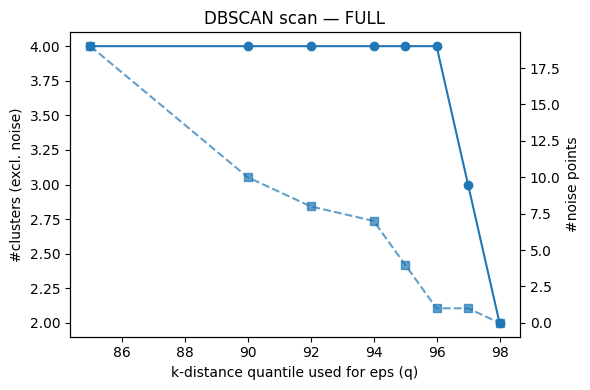

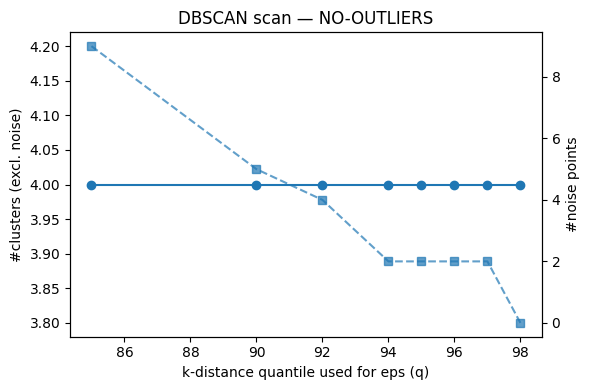

In [10]:
from __future__ import annotations
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

def scan_dbscan(
    X: np.ndarray,
    min_samples: int = 10,
    q_list = (85, 90, 92, 94, 95, 96, 97, 98),
    sample_cap: int = 1500,
    random_state: int | None = 42,
) -> pd.DataFrame:
    """
    Heuristic scan of DBSCAN `eps` using quantiles of k-distance on a subsample.
    Returns a tidy DataFrame with (quantile, eps, #clusters, #noise, silhouette_on_core).

    Notes
    -----
    - We estimate a good `eps` by looking at the distribution of the distance to the
      `min_samples`-th nearest neighbor (k-distance). Larger quantiles -> larger eps.
    - Silhouette is computed **after removing noise points (-1)**; if fewer than 2 clusters
      remain, silhouette is NaN (not meaningful).
    - Works best when X is **scaled / PCA-denoised** (as in your PCA-90% space).
    """
    rng = np.random.default_rng(random_state)
    n = len(X)
    take = min(sample_cap, n)
    idx = rng.choice(n, take, replace=False)

    # k-distance on the sample
    nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X[idx])
    dists, _ = nbrs.kneighbors(X[idx])
    kth = np.sort(dists[:, -1])  # distance to the min_samples-th neighbor

    rows = []
    for q in q_list:
        eps = float(np.quantile(kth, q/100.0))
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X)

        # cluster count ignoring noise
        ncl = len(set(labels)) - (1 if -1 in labels else 0)
        noise = int((labels == -1).sum())

        # silhouette on non-noise labels only
        sil = np.nan
        if ncl >= 2:
            mask = labels != -1
            if mask.sum() > 1 and len(np.unique(labels[mask])) >= 2:
                sil = float(silhouette_score(X[mask], labels[mask]))

        rows.append({"q": q, "eps": eps, "clusters": ncl, "noise": noise, "silhouette": sil})

    df = pd.DataFrame(rows).sort_values("q").reset_index(drop=True)
    return df

# Run on both datasets (PCA-90% space)
dbscan_summaries = {}
for label, bundle in DATASETS.items():
    X = bundle["pca90"][Xcols_full if label == "full" else Xcols_noout].values
    dbscan_summaries[label] = scan_dbscan(X)

# Quick glance
dbscan_summaries["full"], dbscan_summaries["no_outliers"]

# Optional: quick line plots
def plot_dbscan_scan(df: pd.DataFrame, title: str):
    fig, ax1 = plt.subplots(figsize=(6,4))
    ax1.plot(df["q"], df["clusters"], marker="o", label="#clusters")
    ax1.set_xlabel("k-distance quantile used for eps (q)")
    ax1.set_ylabel("#clusters (excl. noise)")
    ax2 = ax1.twinx()
    ax2.plot(df["q"], df["noise"], marker="s", linestyle="--", label="#noise", alpha=0.7)
    ax2.set_ylabel("#noise points")
    plt.title(title)
    fig.tight_layout()
    plt.show()

plot_dbscan_scan(dbscan_summaries["full"], "DBSCAN scan — FULL")
plot_dbscan_scan(dbscan_summaries["no_outliers"], "DBSCAN scan — NO-OUTLIERS")


**DBSCAN Results — Quick Interpretation**

**Full dataset**
- DBSCAN detected **4 clusters** consistently up to the 96th distance quantile.  
- After that, clusters start merging (the line drops).  
- Noise stays low — around **18 points** total (~1–2% of data).

**No-outliers dataset**
- The number of clusters is **stable at 4** across all tested quantiles.  
- Noise drops quickly and remains minimal (≈ **4 points**).

**Interpretation**
- The **stable cluster count** across a broad range of `eps` values suggests a **robust underlying structure**.  
- The **low noise proportion** means almost all points fit neatly into these clusters.
- DBSCAN’s four clusters align closely with the low-*k* structure found in K-Means and Agglomerative models.

**Decision context**
- The difference between **3 (Agglo-Ward)** and **4 (DBSCAN)** likely reflects a subtle internal split within one of the clusters rather than a truly distinct new group.
- Therefore, DBSCAN **supports** the earlier choice of **Agglomerative (Ward) with k = 3**, confirming that the data naturally form **a few compact, well-defined groups**. So my final choice is likely going to be between 3 or 4 clusters. 

### 2.3 - FINAL MODEL

After testing multiple clustering algorithms and `k` values, this block **fits the final chosen model(s)** using the best parameters found earlier (from the evaluation phase).


`fit_final_models(X, best_row)`

**What it does**
This helper function takes:
- the **feature matrix** `X` (your PCA-90% data), and  
- the **best configuration** (`algo`, `k`) returned by `pick_best_row()`.

Then it fits the **final clustering model** and returns:
- the fitted `model` object  
- the array of assigned `labels` (cluster IDs for each row in `X`)

In [11]:
def fit_final_models(X, best_row):
    """_summary_

    Args:
        X (_type_): _feature matrix (PCA-90% data)
        best_row (_type_): _best configuration (algo, k) from pick_best_row()

    Raises:
        ValueError: _Unsupported algo for final fit._

    Returns:
        _type_: _fitted model, cluster labels
    """
    algo = best_row["algo"]
    k    = int(best_row["k"])
    if algo == "kmeans":
        model = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE)
        labels = model.fit_predict(X)
    elif algo.startswith("agglo"):
        model = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels = model.fit_predict(X)
    else:
        raise ValueError("Unsupported algo for final fit.")
    return model, labels

final = {}
for label, bundle in DATASETS.items():
    X = bundle["pca90"][Xcols_full if label=="full" else Xcols_noout].values
    best = results[label]["best"]
    model, labels = fit_final_models(X, best)
    DATASETS[label]["final_labels"] = pd.DataFrame({"row_id": bundle["pca90"]["row_id"], "cluster": labels})
    final[label] = {"model": model, "labels": labels, "best": best}

final["full"]["best"], final["no_outliers"]["best"]


(algo                      agglo-ward
 k                                  3
 silhouette                  0.209632
 calinski_harabasz         193.647006
 davies_bouldin              1.777636
 silhouette_norm                  1.0
 calinski_harabasz_norm      0.862801
 davies_bouldin_norm         0.815295
 composite                   0.892699
 Name: 10, dtype: object,
 algo                      agglo-ward
 k                                  4
 silhouette                  0.186699
 calinski_harabasz         182.806737
 davies_bouldin              1.701993
 silhouette_norm             0.671275
 calinski_harabasz_norm      0.871885
 davies_bouldin_norm         0.934611
 composite                   0.825924
 Name: 11, dtype: object)

In [12]:
def attach_and_save(label, out_name):
    b = DATASETS[label]
    lbl = b["final_labels"]
    # Join labels to each projection and descriptives
    out = {}
    for key in ["pca90","pca2d","tsne2d","umap2d","desc"]:
        df = b[key].merge(lbl, on="row_id", how="left")
        out[key] = df

    # Save tidy Excel with multiple sheets
    path = OUT_PATH / out_name
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        out["pca90"].to_excel(writer, sheet_name="pca90_with_clusters", index=False)
        out["pca2d"].to_excel(writer, sheet_name="pca2d_with_clusters", index=False)
        out["tsne2d"].to_excel(writer, sheet_name="tsne2d_with_clusters", index=False)
        out["umap2d"].to_excel(writer, sheet_name="umap2d_with_clusters", index=False)
        out["desc"].to_excel(writer, sheet_name="descriptive_with_clusters", index=False)
    return path, out

path_full,      joined_full      = attach_and_save("full",        "03_climate_dataset_clustered.xlsx")
path_noout,     joined_noout     = attach_and_save("no_outliers", "03_climate_dataset_clustered_noOutliers.xlsx")
path_full, path_noout


(WindowsPath('C:/Users/Vaccari/Desktop/iCloudDrive/Desktop/ENRICO/05_LEARNING/University/ToU/Phases/02_Calibration_Phase/Applied_Machine_Learning/Clustering/Mapping_The_Italian_Climate_Mindscape/data/processed/03_climate_dataset_clustered.xlsx'),
 WindowsPath('C:/Users/Vaccari/Desktop/iCloudDrive/Desktop/ENRICO/05_LEARNING/University/ToU/Phases/02_Calibration_Phase/Applied_Machine_Learning/Clustering/Mapping_The_Italian_Climate_Mindscape/data/processed/03_climate_dataset_clustered_noOutliers.xlsx'))

**2D Cluster Visualization**
After assigning cluster labels, this section **plots each observation in 2D space**, coloring points by their cluster membership.  
It provides an immediate visual check on how well the clusters separate in your PCA and t-SNE embeddings.

**Cluster visualization with consistent colors**

This code creates a clean 2×3 grid of scatterplots showing clusters across **PCA**, **t-SNE**, and **UMAP** embeddings  
for both datasets (Full and No-Outliers), using a single, consistent color palette for cluster labels.

`_make_color_maps()`

Purpose: build **color dictionaries** that ensure each cluster number keeps the same color across all plots.

Steps:
- Load a Matplotlib palette (`tab20` by default).
- Extract its base color list.
- For the *Full* dataset:
  - Get unique cluster labels (e.g., `[0, 1, 2]`).
  - Assign each cluster a unique color from the palette → `color_map_base`.
- For the *No-Outliers* dataset:
  - Check if it has any **extra clusters** not in the full data (e.g., a new cluster 3 after removing outliers).
  - Assign new colors for those extras, starting from the next unused color index.
- Return:
  - `color_map_full`: colors for full dataset clusters.
  - `color_map_no`: colors for no-outlier clusters (includes extras).
  - Lists of canonical and extra labels for reference.

This keeps visual consistency — Cluster 0 is always the same color, even across datasets and projections.

`scatter2d_grid()`

Purpose: draw all scatterplots in one compact figure for easy comparison.

Structure:
- Creates a **2×3 grid** of subplots:
  - Row 1 → Full dataset  
  - Row 2 → No-Outliers dataset  
  - Columns → PCA-2D, t-SNE 2D, and UMAP 2D
- Retrieves colors from `_make_color_maps()` so clusters match across every panel.
- Loops over each dataset and projection:
  - Picks the 2D coordinates (`x`, `y`) automatically using `guess_xy()`.
  - Maps each point’s cluster label to its color.
  - Plots points as small circles (`s=12`) with no edge lines.
  - Sets subplot titles and axis labels.
  - Builds a **custom legend** showing cluster numbers with their matching colors.

Finally, it uses `plt.tight_layout()` for spacing and `plt.show()` to render the figure.

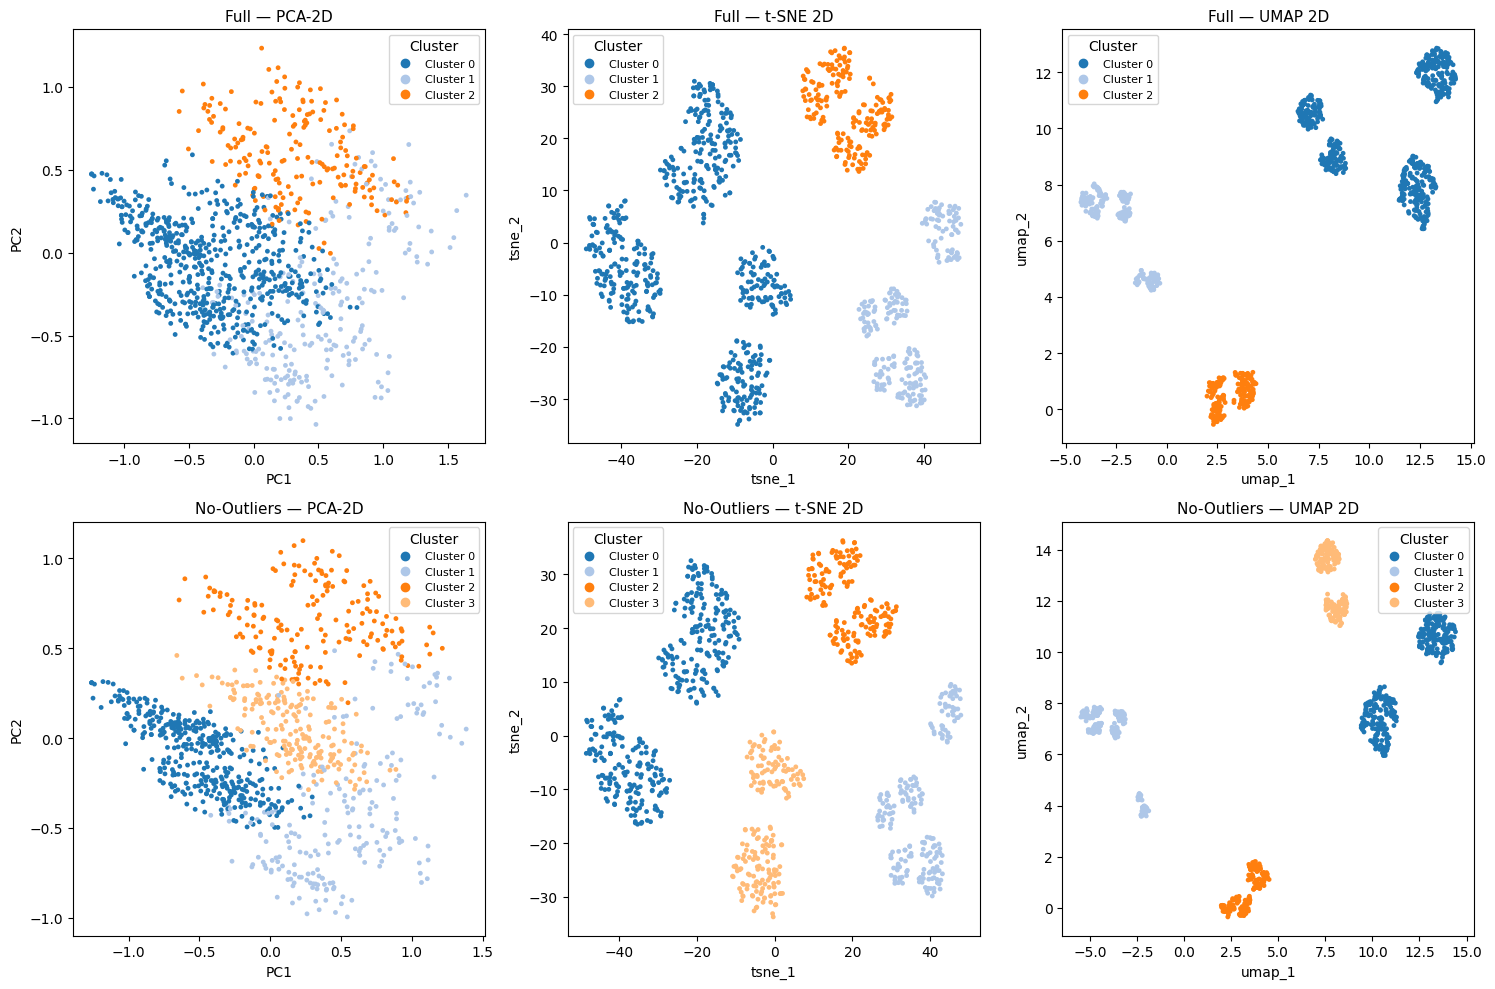

In [13]:
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

def _make_color_maps(joined_full, joined_noout, palette_name="tab20"):
    cmap = get_cmap(palette_name)
    base_colors = list(getattr(cmap, "colors", [cmap(i) for i in range(cmap.N)]))

    full_pca = joined_full["pca2d"]
    canon_labels = sorted(full_pca["cluster"].unique())
    color_map_base = {lab: base_colors[i % len(base_colors)] for i, lab in enumerate(canon_labels)}

    no_pca = joined_noout["pca2d"]
    no_labels = sorted(no_pca["cluster"].unique())
    extra_labels = [lab for lab in no_labels if lab not in color_map_base]

    start_idx = len(canon_labels)
    extra_map = {lab: base_colors[(start_idx + k) % len(base_colors)] for k, lab in enumerate(extra_labels)}

    color_map_full = color_map_base
    color_map_no   = {**color_map_base, **extra_map}
    return color_map_full, color_map_no, canon_labels, extra_labels

def guess_xy(df):
    cols = numeric_cols(df)
    x = next((c for c in cols if c.lower() in ["pc1","pca1","dim1","x"]), cols[1])
    y = next((c for c in cols if c.lower() in ["pc2","pca2","dim2","y"]), cols[2])
    return x, y

def scatter2d_grid(joined_full, joined_noout, palette_name="tab20"):
    color_map_full, color_map_no, canon_labels, extra_labels = _make_color_maps(
        joined_full, joined_noout, palette_name=palette_name
    )

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    datasets = [("Full", joined_full, color_map_full),
                ("No-Outliers", joined_noout, color_map_no)]
    projections = [("PCA-2D", "pca2d"), ("t-SNE 2D", "tsne2d"), ("UMAP 2D", "umap2d")]

    for i, (label, joined, cmap_map) in enumerate(datasets):
        for j, (proj_name, key) in enumerate(projections):
            df = joined[key]
            x, y = guess_xy(df)

            colors = df["cluster"].map(cmap_map)
            colors = colors.apply(lambda c: c if isinstance(c, tuple) else (0.6, 0.6, 0.6, 1.0))

            axes[i, j].scatter(df[x], df[y], c=list(colors), s=12, linewidths=0)
            axes[i, j].set_title(f"{label} — {proj_name}", fontsize=11)
            axes[i, j].set_xlabel(x)
            axes[i, j].set_ylabel(y)

            present = sorted(df["cluster"].unique())
            handles = [plt.Line2D([0],[0], marker='o', linestyle='',
                                  markersize=6, color=cmap_map.get(k, (0.6,0.6,0.6,1.0)))
                       for k in present]
            labels = [f"Cluster {k}" for k in present]
            axes[i, j].legend(handles, labels, fontsize=8, title="Cluster", loc="best")

    plt.tight_layout()
    plt.show()
scatter2d_grid(joined_full, joined_noout)


**Visual interpretation of cluster structure**

In the PCA-2D plots, three clusters are visible with some overlap, showing that the main separation aligns with the first two principal components but still shares partial boundaries. This overlap is expected, as PCA compresses many dimensions into two.

In the t-SNE and UMAP views, clusters appear much clearer and more compact. Each group forms a distinct area, though a few clusters show double-lobed shapes—two smaller, close regions of the same color. These likely represent sub-segments within a broader cluster rather than entirely new groups.

For the no-outlier dataset, the overall structure remains the same but becomes cleaner, with tighter boundaries and one additional small cluster emerging. This suggests that removing outliers sharpened existing distinctions and revealed finer internal variation.

Taken together, all embeddings confirm a stable three-cluster pattern, consistent with the Agglomerative (Ward) model. The minor splits visible in t-SNE and UMAP reflect natural substructure rather than a need to redefine the number of clusters.

The main cluster separation (the three large groups) is linear enough that PCA already shows it.
The finer texture (sub-clusters, curved boundaries) is non-linear, visible only in t-SNE and UMAP.
That mix is typical in behavioral or attitudinal data: broad distinctions on linear scales, subtle attitudes or experiences forming curved transitions within them.

### 2.2 - CLUSTER PROFILING

We summarize each cluster using **numeric descriptive features** only.  
For every feature, we measure how far the cluster mean is from the overall mean, scaled by the overall standard deviation.

**Metric used: Standardized Mean Difference (SMD)**

- Positive SMD → the cluster is **higher** than the sample average on that feature.  
- Negative SMD → the cluster is **lower** than average.  
- Larger |SMD| → stronger differentiator.

**Outputs**
- `06_full_top_numeric_effects.xlsx` and `06_no_outliers_top_numeric_effects.xlsx`  
  Long tables with one row per (cluster, feature): `feature, cluster, smd, abs_smd, sign`.
- `06_full_TOPNUM.xlsx` and `06_no_outliers_TOPNUM.xlsx`  
  Compact tables: **Top 8** features per cluster ranked by `abs_smd` (strongest differentiators).

**How to use them in the write-up**
- For each cluster, pick 3–5 features with the **highest abs_smd**.  
- Keep the **sign** to state direction, e.g.  
  “Cluster 2 shows **higher climate concern** (SMD = +0.62) and **lower preparedness** (SMD = −0.41).”
- Compare **full vs no-outliers**: if the top features are similar and signs match, the profile is **stable**.

**Notes**
- We use sample standard deviation (`ddof=1`) for effect-size style scaling.  
- Features with zero overall variance are dropped (SMD undefined).  
- This is descriptive, not causal. It’s meant to **label and explain clusters**, not to infer causes.

In [14]:
def top_numeric_effects(desc_with_labels: pd.DataFrame, use_sample_std: bool = True) -> pd.DataFrame:
    """
    For each cluster & numeric feature, compute standardized mean difference (SMD):
      smd = (mean_cluster - mean_overall) / sd_overall
    Returns: long table [feature, cluster, smd, abs_smd, sign], sorted within cluster.
    """
    df = desc_with_labels.copy()
    # keep only numeric features (exclude identifiers/labels)
    num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in ["row_id","cluster"]]
    if not num_cols:
        return pd.DataFrame(columns=["feature","cluster","smd","abs_smd","sign"])

    overall_mean = df[num_cols].mean()
    ddof = 1 if use_sample_std else 0
    overall_std  = df[num_cols].std(ddof=ddof).replace(0, np.nan)

    # vectorized per-cluster means
    cl_means = df.groupby("cluster")[num_cols].mean()

    # SMD for all (cluster, feature)
    smd = (cl_means - overall_mean) / overall_std

    eff = (smd.stack()
              .rename("smd")
              .reset_index()
              .rename(columns={"level_0":"cluster","level_1":"feature"}))

    eff["abs_smd"] = eff["smd"].abs()
    eff["sign"] = np.sign(eff["smd"]).astype("int64")
    return eff.sort_values(["cluster","abs_smd"], ascending=[True, False]).reset_index(drop=True)

# ---- Build & save profiles (numeric only) ----
TOPK_NUM = 8

for label, joined in [("full", joined_full), ("no_outliers", joined_noout)]:
    descL = joined["desc"].copy()  # descriptive features with the final labels merged

    num_eff = top_numeric_effects(descL, use_sample_std=True)

    # Save the full numeric effects table
    num_eff.to_excel(OUT_PATH / f"06_{label}_top_numeric_effects.xlsx", index=False)

    # Save Top-K per cluster
    topk_num = (num_eff
                .groupby("cluster", group_keys=False)
                .apply(lambda d: d.nlargest(TOPK_NUM, "abs_smd"))
                .reset_index(drop=True)
                [["feature","cluster","smd","abs_smd","sign"]])

    topk_num.to_excel(OUT_PATH / f"06_{label}_TOPNUM.xlsx", index=False)

print("Saved numeric-only profiles: 06_*_top_numeric_effects.xlsx and 06_*_TOPNUM.xlsx")


Saved numeric-only profiles: 06_*_top_numeric_effects.xlsx and 06_*_TOPNUM.xlsx


**What this block does (PCA-only arrows + top features per cluster)**

• *Why arrows on PCA-2D?*  
We want to see **which features increase** along directions in the PCA plane.  
For each feature *f*, we regress its standardized values on the 2D coordinates:
  
  y_std = bx·PC1 + by·PC2 + b0
  
The vector (bx, by) gives a **direction of growth** for *f*. We scale these to readable arrows and draw the top ones.

• *Why PCA only (not t-SNE/UMAP)?*  
You asked to focus on PCA-2D. PCA keeps a linear, globally interpretable geometry and pairs naturally with variance explanations.

**Outputs you get**
1) **Plots**
   - FULL — PCA-2D with **descriptive feature** arrows  
   - FULL — PCA-2D with **12 clustering feature** arrows (if X12 provided)  
   - NO-OUTLIERS — PCA-2D with **descriptive** arrows  
   - NO-OUTLIERS — PCA-2D with **12 features** arrows (if provided)

   Colors are clusters (viridis). Arrows start near the cloud’s median.

2) **Tables: Top features per cluster (numeric only)**
   - For **descriptive** features:
     - `06_full_top_numeric_effects.xlsx`  
     - `06_no_outliers_top_numeric_effects.xlsx`
     - Top-K summaries:
       - `06_full_TOPNUM.xlsx`  
       - `06_no_outliers_TOPNUM.xlsx`
   - For **original 12 clustering features** (if available):
     - `06_full_top_clustering12_effects.xlsx` / `06_full_TOPNUM_clustering12.xlsx`  
     - `06_no_outliers_top_clustering12_effects.xlsx` / `06_no_outliers_TOPNUM_clustering12.xlsx`

**How the “top features per cluster” are computed**
We use **Standardized Mean Difference (SMD)** for each (cluster, feature):

  SMD = (mean_cluster − mean_overall) / sd_overall

• Positive SMD → cluster is **higher** than the sample average on that feature.  
• Negative SMD → cluster is **lower** than average.  
• Larger |SMD| → stronger differentiator.  
We list the **Top-K** features per cluster by |SMD| for both **descriptive** and (optionally) **12 clustering** features.

**How to read the PCA-arrow plots**
- The **arrow direction** shows where the feature increases in the PCA plane.  
- The **arrow length** approximates the strength of association with the plane.  
- If several high-priority features point in similar directions, that axis likely encodes a **shared construct** (e.g., climate concern).

**What’s simplified vs your older version**
- Removed all t-SNE/UMAP plotting.  
- Clear docstrings and function boundaries.  
- One concise function to compute **top features per cluster** for any numeric frame with labels.  
- Optional handling of the **12 clustering features** if you’ve loaded `X12_full` / `X12_noout`.

**Suggested use in your write-up**
- Use the **Top-K per cluster** to write crisp labels (“High concern, high preparedness”, etc.).  
- Use **PCA-arrow plots** to visually justify those labels (which features align with which cluster spreads).  
- Compare **full vs no-outliers**: similar top features = stable profiles; any flips deserve a note in limitations.


In [15]:
# ==== PCA-only arrows + Top-Features per cluster (numeric-only) ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import lstsq

# -------------------------------
# 1) Helpers for coordinates + arrows
# -------------------------------
def _get_xy_cols(df: pd.DataFrame) -> tuple[str, str]:
    """
    Pick x,y coordinate columns from a 2D embedding DataFrame.
    Tries common PCA names, then falls back to the first two numeric columns (excluding row_id/cluster).
    """
    cand = [c.lower() for c in df.columns]
    name_map = {c.lower(): c for c in df.columns}
    for a, b in [("pc1","pc2"), ("pca1","pca2"), ("dim1","dim2"), ("x","y")]:
        if a in cand and b in cand:
            return name_map[a], name_map[b]
    cols = [c for c in df.select_dtypes(include=np.number).columns if c not in ["row_id","cluster"]]
    if len(cols) < 2:
        raise ValueError("Need at least two numeric columns in the embedding to plot.")
    return cols[0], cols[1]


def compute_feature_vectors(embed_df: pd.DataFrame,
                            feature_df: pd.DataFrame,
                            feature_cols: list[str],
                            center: bool = True) -> tuple[pd.DataFrame, tuple[str, str]]:
    """
    For each feature in `feature_cols`, regress standardized y on the 2D coordinates [x, y]:
        y_std ~ bx * x + by * y + b0
    Returns a tidy table with raw betas and scaled arrow vectors (vx, vy) for plotting.
    Scaling normalizes lengths to a readable range while preserving directions.
    """
    # inner-join so rows align
    df = embed_df.merge(feature_df[["row_id"] + feature_cols], on="row_id", how="inner").dropna()
    xcol, ycol = _get_xy_cols(df)

    X = df[[xcol, ycol]].values.astype(float)
    if center:
        X = X - X.mean(axis=0, keepdims=True)
    Z = np.c_[X, np.ones(len(X))]  # add intercept

    rows = []
    for f in feature_cols:
        y = df[f].values.astype(float)
        # standardize target to make arrows comparable across features
        y = (y - np.nanmean(y)) / (np.nanstd(y) + 1e-12)
        beta, *_ = lstsq(Z, y, rcond=None)  # [bx, by, b0]
        rows.append({"feature": f, "beta_x": beta[0], "beta_y": beta[1]})

    vecs = pd.DataFrame(rows)
    vecs["length"] = np.sqrt(vecs["beta_x"]**2 + vecs["beta_y"]**2)

    if (vecs["length"] > 0).any():
        ln = vecs["length"]
        # normalize [0,1] then scale to a pleasant length range
        vecs["scale"] = (ln - ln.min()) / (ln.max() - ln.min() + 1e-12)
        vecs["plot_len"] = 0.35 + 0.65 * vecs["scale"]
        ux = vecs["beta_x"] / (ln + 1e-12)
        uy = vecs["beta_y"] / (ln + 1e-12)
        vecs["vx"] = ux * vecs["plot_len"]
        vecs["vy"] = uy * vecs["plot_len"]
    else:
        vecs["vx"] = 0.0; vecs["vy"] = 0.0; vecs["plot_len"] = 0.0

    return vecs, (xcol, ycol)


def plot_pca_with_arrows(pca2d_df: pd.DataFrame,
                         feature_df: pd.DataFrame,
                         feature_cols: list[str],
                         title: str,
                         max_arrows: int = 15,
                         annotate: bool = True,
                         cmap: str = "tab20") -> pd.DataFrame:
    """
    Plot PCA-2D scatter colored by cluster, then overlay top feature arrows (by arrow length).
    Returns the full vectors DataFrame so you can inspect rankings if needed.
    """
    # make sure cluster colors are available if present
    df = pca2d_df.copy()
    xcol, ycol = _get_xy_cols(df)
    colors = df["cluster"] if "cluster" in df.columns else None

    vecs, _ = compute_feature_vectors(df, feature_df, feature_cols)
    vecs_plot = vecs.sort_values("plot_len", ascending=False).head(max_arrows)

    plt.figure(figsize=(7, 6))
    plt.scatter(df[xcol], df[ycol], c=colors, s=12, cmap=cmap)
    x0, y0 = df[xcol].median(), df[ycol].median()  # start arrows near the data center

    for _, r in vecs_plot.iterrows():
        plt.arrow(x0, y0, r["vx"], r["vy"], width=0.002, head_width=0.04, length_includes_head=True)
        if annotate:
            plt.text(x0 + r["vx"] * 1.08, y0 + r["vy"] * 1.08, r["feature"], fontsize=8)

    plt.title(title); plt.xlabel(xcol); plt.ylabel(ycol)
    plt.tight_layout(); plt.show()
    return vecs



In [16]:
noout_scaled

,environmental_concerns,adaptation_engagement_score,climate_event_count,flood_experience,heat_experience,climate_consequence_count,infra_consequences,health_consequences,climate_concern,personal_preparedness_score,domestic_responsibility,global_solidarity
0,0.675091,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.358778,0.421311,0.580714,0.386959
1,0.675091,1.000000,0.248376,0.000000,0.000000,0.265787,0.000000,0.0,0.540167,0.741947,0.348360,0.712949
2,0.000000,1.000000,0.419197,0.000000,0.744049,0.000000,0.000000,0.0,0.358778,1.000000,0.888640,0.712949
3,0.000000,0.509137,0.553486,0.961952,0.430335,0.000000,0.000000,0.0,0.208845,1.000000,0.000000,0.712949
4,0.000000,0.509137,0.248376,0.000000,0.430335,0.549884,0.733411,1.0,0.540167,0.421311,0.580714,0.386959
...,...,...,...,...,...,...,...,...,...,...,...,...
952,0.000000,0.509137,0.553486,0.961952,0.430335,0.000000,0.000000,0.0,0.208845,0.421311,0.000000,0.712949
953,0.000000,0.210674,0.665839,0.000000,1.000000,0.265787,0.000000,0.0,0.208845,0.421311,0.888640,1.000000
954,0.675091,0.509137,0.248376,0.000000,0.430335,0.429671,0.000000,1.0,0.753704,0.421311,0.348360,0.000000
955,0.000000,1.000000,0.553486,0.000000,1.000000,0.265787,0.733411,0.0,0.753704,0.000000,0.580714,0.386959


### 2.1 - FEATURE CONTRIBUTION AND CLUSTER INTERPRETATION IN PCA SPACE

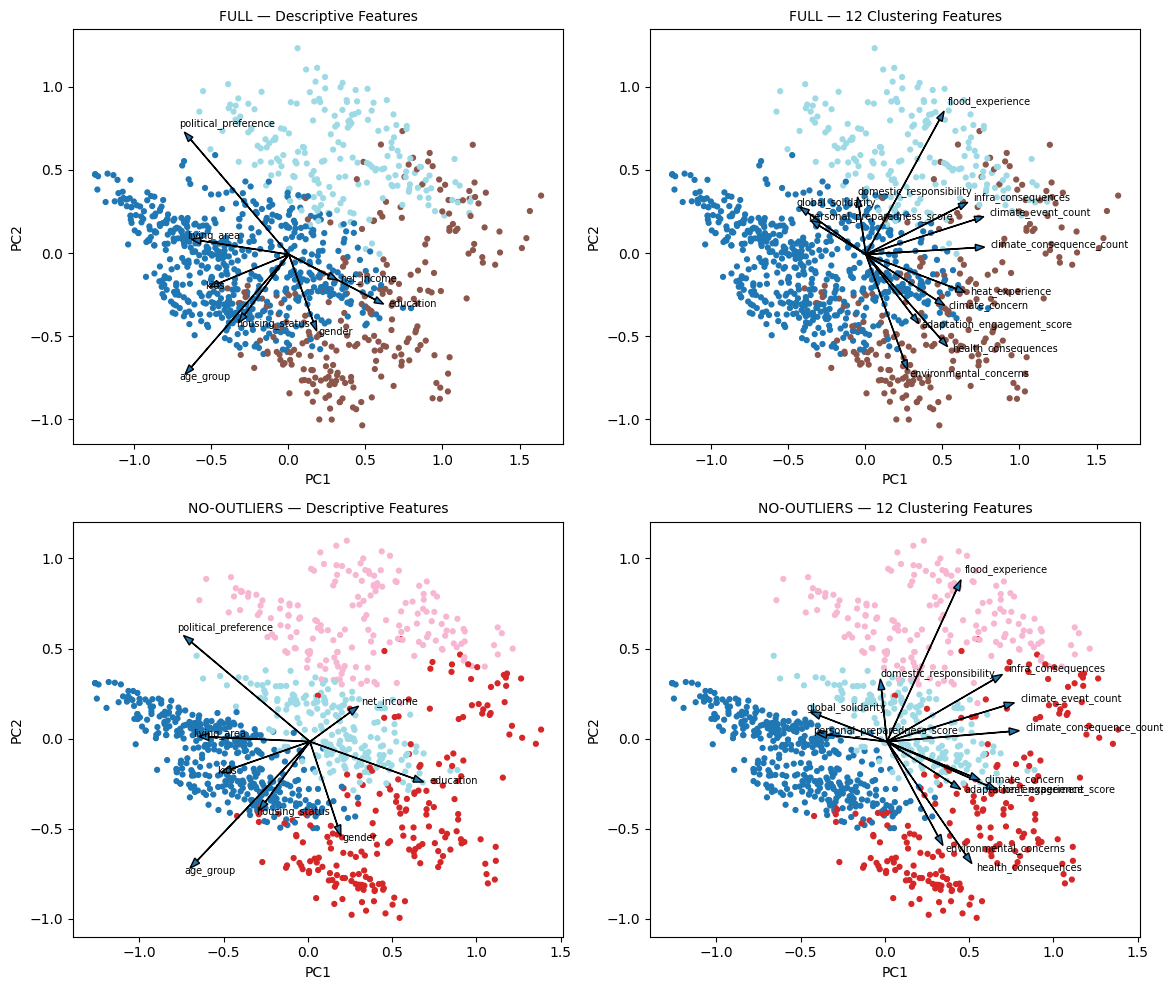

In [17]:
# ==== PCA-only arrows + Top-Features per cluster (numeric-only) ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import lstsq

# -------------------------------
# 1) Helpers for coordinates + arrows
# -------------------------------
def _get_xy_cols(df: pd.DataFrame) -> tuple[str, str]:
    """
    Choose x,y coordinate columns from a 2D embedding DataFrame.
    Tries common PCA names, else falls back to the first two numeric columns (excluding row_id/cluster).
    """
    cand = [c.lower() for c in df.columns]
    name_map = {c.lower(): c for c in df.columns}
    for a, b in [("pc1","pc2"), ("pca1","pca2"), ("dim1","dim2"), ("x","y")]:
        if a in cand and b in cand:
            return name_map[a], name_map[b]
    cols = [c for c in df.select_dtypes(include=np.number).columns if c not in ["row_id","cluster"]]
    if len(cols) < 2:
        raise ValueError("Need at least two numeric columns in the embedding to plot.")
    return cols[0], cols[1]


def compute_feature_vectors(embed_df: pd.DataFrame,
                            feature_df: pd.DataFrame,
                            feature_cols: list[str],
                            center: bool = True) -> tuple[pd.DataFrame, tuple[str, str]]:
    """
    For each feature in `feature_cols`, regress the standardized feature on the 2D coordinates [x, y]:
        z(feature) ~ bx * x + by * y + b0
    Returns:
      - vecs: DataFrame with raw betas and scaled arrow vectors (vx, vy),
      - (xcol, ycol): the names of the 2D axes used.
    """
    # Align rows by row_id and drop NAs only on used columns
    df = embed_df.merge(feature_df[["row_id"] + feature_cols], on="row_id", how="inner").dropna()
    xcol, ycol = _get_xy_cols(df)

    X = df[[xcol, ycol]].values.astype(float)
    if center:
        X = X - X.mean(axis=0, keepdims=True)
    Z = np.c_[X, np.ones(len(X))]  # add intercept

    rows = []
    for f in feature_cols:
        y = df[f].values.astype(float)
        # z-score target so arrows are comparable across features
        y = (y - np.nanmean(y)) / (np.nanstd(y) + 1e-12)
        beta, *_ = lstsq(Z, y, rcond=None)  # [bx, by, b0]
        rows.append({"feature": f, "beta_x": beta[0], "beta_y": beta[1]})

    vecs = pd.DataFrame(rows)
    vecs["length"] = np.sqrt(vecs["beta_x"]**2 + vecs["beta_y"]**2)

    if (vecs["length"] > 0).any():
        ln = vecs["length"]
        # normalize [0,1] then scale to a pleasant range
        vecs["scale"] = (ln - ln.min()) / (ln.max() - ln.min() + 1e-12)
        vecs["plot_len"] = 0.35 + 0.65 * vecs["scale"]
        ux = vecs["beta_x"] / (ln + 1e-12)
        uy = vecs["beta_y"] / (ln + 1e-12)
        vecs["vx"] = ux * vecs["plot_len"]
        vecs["vy"] = uy * vecs["plot_len"]
    else:
        vecs["vx"] = 0.0; vecs["vy"] = 0.0; vecs["plot_len"] = 0.0

    return vecs, (xcol, ycol)


def plot_pca_with_arrows(pca2d_df: pd.DataFrame,
                         feature_df: pd.DataFrame,
                         feature_cols: list[str],
                         title: str,
                         max_arrows: int = 15,
                         annotate: bool = True,
                         cmap: str = "tab20") -> pd.DataFrame:
    """
    Plot PCA-2D scatter colored by cluster; overlay top features as arrows (ranked by arrow length).
    Returns the full vectors DataFrame (including arrow lengths) for inspection.
    """
    df = pca2d_df.copy()
    xcol, ycol = _get_xy_cols(df)
    colors = df["cluster"] if "cluster" in df.columns else None

    vecs, _ = compute_feature_vectors(df, feature_df, feature_cols)
    vecs_plot = vecs.sort_values("plot_len", ascending=False).head(max_arrows)

    plt.figure(figsize=(7, 6))
    plt.scatter(df[xcol], df[ycol], c=colors, s=12, cmap=cmap)
    x0, y0 = df[xcol].median(), df[ycol].median()

    for _, r in vecs_plot.iterrows():
        plt.arrow(x0, y0, r["vx"], r["vy"], width=0.002, head_width=0.04, length_includes_head=True)
        if annotate:
            plt.text(x0 + r["vx"] * 1.08, y0 + r["vy"] * 1.08, r["feature"], fontsize=8)

    plt.title(title); plt.xlabel(xcol); plt.ylabel(ycol)
    plt.tight_layout(); plt.show()
    return vecs


# -------------------------------
# 2) Top features per cluster (numeric-only)
# -------------------------------
def top_numeric_effects(df_with_labels: pd.DataFrame,
                        exclude=("row_id","cluster"),
                        use_sample_std: bool = True) -> pd.DataFrame:
    """
    Compute standardized mean difference per (cluster, feature):
      SMD = (mean_cluster - mean_overall) / sd_overall
    Returns long-form table: [feature, cluster, smd, abs_smd, sign], sorted by abs_smd within cluster.
    """
    if df_with_labels is None or df_with_labels.empty:
        return pd.DataFrame(columns=["feature","cluster","smd","abs_smd","sign"])
    df = df_with_labels.copy()
    num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in exclude]
    if not num_cols:
        return pd.DataFrame(columns=["feature","cluster","smd","abs_smd","sign"])

    overall_mean = df[num_cols].mean()
    ddof = 1 if use_sample_std else 0
    overall_std  = df[num_cols].std(ddof=ddof).replace(0, np.nan)

    cl_means = df.groupby("cluster")[num_cols].mean()
    smd = (cl_means - overall_mean) / overall_std

    out = (smd.stack()
              .rename("smd")
              .reset_index()
              .rename(columns={"level_0":"cluster","level_1":"feature"}))
    out["abs_smd"] = out["smd"].abs()
    out["sign"] = np.sign(out["smd"]).astype(int)
    return out.sort_values(["cluster","abs_smd"], ascending=[True, False]).reset_index(drop=True)


def top_k_per_cluster(effects: pd.DataFrame, k: int = 6) -> pd.DataFrame:
    """Return the Top-K rows by |SMD| within each cluster."""
    if effects is None or effects.empty:
        return effects
    return (effects
            .groupby("cluster", group_keys=False)
            .apply(lambda d: d.nlargest(k, "abs_smd"))
            .reset_index(drop=True))


def print_topk(effects: pd.DataFrame, title: str, k: int = 6):
    """Pretty-print Top-K features per cluster from a long SMD effects table."""
    print(f"\n=== {title} (Top {k} by |SMD|) ===")
    if effects is None or effects.empty:
        print("No data.")
        return
    for cl, d in effects.groupby("cluster", sort=True):
        top = d.nlargest(k, "abs_smd")[["feature","smd"]].reset_index(drop=True)
        print(f"\nCluster {cl}:")
        for i, r in top.iterrows():
            print(f"  {i+1:>2}. {r['feature']:<40} SMD = {r['smd']:+.3f}  (|SMD|={abs(r['smd']):.3f})")


# -------------------------------
# 3) Utilities to attach row_id/labels to clustering features
# -------------------------------
def attach_row_id_if_missing(df: pd.DataFrame, ref_with_row_id: pd.DataFrame, name: str):
    """
    Ensure the features DF has a row_id column.
    If missing and lengths match a reference DF with row_id (e.g., pca90), copy its row_id.
    Else, fall back to sequential row_id (warn).
    """
    if df is None:
        return None
    out = df.copy()
    if "row_id" not in out.columns:
        if len(out) == len(ref_with_row_id):
            out.insert(0, "row_id", ref_with_row_id["row_id"].to_numpy())
        else:
            out.insert(0, "row_id", np.arange(len(out)))
            print(f"[warn] {name}: row_id was missing and length != reference; inserted sequential row_id.")
    return out


def merge_labels(features_df: pd.DataFrame, pca90_with_labels: pd.DataFrame) -> pd.DataFrame:
    """Attach cluster labels from the PCA-90 frame to the features via row_id."""
    return features_df.merge(pca90_with_labels[["row_id","cluster"]], on="row_id", how="left")


# -------------------------------
# 4) PCA Arrows & Top Feature Visualization
# -------------------------------

# Prepare numeric descriptive sets
desc_num_full = joined_full["desc"].select_dtypes(include=np.number).drop(columns=["cluster"], errors="ignore").copy()
desc_num_no   = joined_noout["desc"].select_dtypes(include=np.number).drop(columns=["cluster"], errors="ignore").copy()
for d in (desc_num_full, desc_num_no):
    if "row_id" not in d.columns:
        d.insert(0, "row_id", np.arange(len(d)))

# Prepare scaled clustering feature sets (if exist)
def safe_scaled(df, ref, name):
    try:
        out = df.copy()
        if "row_id" not in out.columns:
            out.insert(0, "row_id", ref["row_id"].to_numpy())
        return out
    except Exception:
        print(f"[warn] {name} not available.")
        return None

full_scaled_ready  = safe_scaled(full_scaled if "full_scaled" in locals() else None, joined_full["pca90"], "full_scaled")
noout_scaled_ready = safe_scaled(noout_scaled if "noout_scaled" in locals() else None, joined_noout["pca90"], "noout_scaled")

# Define plotting combinations (title, pca2d, feature_df)
plot_sets = [
    ("FULL — Descriptive Features", joined_full["pca2d"], desc_num_full),
    ("FULL — 12 Clustering Features", joined_full["pca2d"], full_scaled_ready),
    ("NO-OUTLIERS — Descriptive Features", joined_noout["pca2d"], desc_num_no),
    ("NO-OUTLIERS — 12 Clustering Features", joined_noout["pca2d"], noout_scaled_ready),
]

# Plot: FULL (row 1) and NO-OUTLIERS (row 2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (title, pca_df, feat_df) in zip(axes, plot_sets):
    if pca_df is None or feat_df is None:
        ax.set_visible(False)
        continue

    # Compute feature vectors
    feature_cols = [c for c in feat_df.columns if c != "row_id"]
    vecs, (xcol, ycol) = compute_feature_vectors(pca_df, feat_df, feature_cols)
    vecs_plot = vecs.sort_values("plot_len", ascending=False).head(15)

    # Scatter + arrows
    colors = pca_df["cluster"] if "cluster" in pca_df.columns else None
    ax.scatter(pca_df[xcol], pca_df[ycol], c=colors, s=12, cmap="tab20")
    x0, y0 = pca_df[xcol].median(), pca_df[ycol].median()
    for _, r in vecs_plot.iterrows():
        ax.arrow(x0, y0, r["vx"], r["vy"], width=0.002, head_width=0.04, length_includes_head=True)
        ax.text(x0 + r["vx"] * 1.05, y0 + r["vy"] * 1.05, r["feature"], fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xcol); ax.set_ylabel(ycol)

plt.tight_layout()
plt.show()


In [18]:
# -------------------------------
# 5) PRINT: Top-K features per cluster (descriptive + clustering-12)
# -------------------------------
TOPK = 6

# Descriptive (already contain cluster labels in joined_*["desc"])
desc_eff_full = top_numeric_effects(joined_full["desc"])
desc_eff_no   = top_numeric_effects(joined_noout["desc"])
print_topk(desc_eff_full, "FULL — Descriptive features", k=TOPK)
print_topk(desc_eff_no,   "NO-OUTLIERS — Descriptive features", k=TOPK)

# Clustering-12: attach labels, then compute SMDs
if full_scaled is not None:
    full12_ready = attach_row_id_if_missing(full_scaled, joined_full["pca90"], "full_scaled")
    full12_with_labels = merge_labels(full12_ready, joined_full["pca90"])
    full12_eff = top_numeric_effects(full12_with_labels)
    print_topk(full12_eff, "FULL — Clustering-12 features", k=TOPK)
else:
    print("\n=== FULL — Clustering-12 features ===\nNo data (full_scaled not provided).")

if noout_scaled is not None:
    noout12_ready = attach_row_id_if_missing(noout_scaled, joined_noout["pca90"], "noout_scaled")
    noout12_with_labels = merge_labels(noout12_ready, joined_noout["pca90"])
    noout12_eff = top_numeric_effects(noout12_with_labels)
    print_topk(noout12_eff, "NO-OUTLIERS — Clustering-12 features", k=TOPK)
else:
    print("\n=== NO-OUTLIERS — Clustering-12 features ===\nNo data (noout_scaled not provided).")



=== FULL — Descriptive features (Top 6 by |SMD|) ===

Cluster 0:
   1. age_group                                SMD = +0.103  (|SMD|=0.103)
   2. living_area                              SMD = +0.088  (|SMD|=0.088)
   3. education                                SMD = -0.062  (|SMD|=0.062)
   4. kids                                     SMD = +0.061  (|SMD|=0.061)
   5. gender                                   SMD = -0.058  (|SMD|=0.058)
   6. housing_status                           SMD = +0.041  (|SMD|=0.041)

Cluster 1:
   1. gender                                   SMD = +0.230  (|SMD|=0.230)
   2. living_area                              SMD = -0.144  (|SMD|=0.144)
   3. political_preference                     SMD = -0.136  (|SMD|=0.136)
   4. age_group                                SMD = -0.118  (|SMD|=0.118)
   5. kids                                     SMD = -0.118  (|SMD|=0.118)
   6. education                                SMD = +0.112  (|SMD|=0.112)

Cluster 2:
   1. age_

**Cluster Interpretation — No-Outliers Dataset**

After excluding outliers, the clustering model reveals **four distinct groups**, each shaped by both **demographic–descriptive** and **climate experience–attitude** variables. Below is a synthesis of the main characteristics and inferred profiles.

**Cluster 0 — Limited Exposure, Slightly Older Urban Families**

**Descriptive traits**
- Slightly older (`+ age_group`) and more likely to live in **urban areas** (`+ living_area`).
- More often have **children** (`+ kids`) and a modestly **lower education level** (`– education`).
- Lean **moderately toward right-wing preferences** (`+ political_preference`).

**Clustering features**
- Lowest scores across **climate event and consequence experiences**:  
  → *infra_consequences, flood_experience, health_consequences, heat_experience* are all strongly negative.  
- Indicates **low personal or community exposure** to climate impacts.

**Interpretation**
→ A cluster of **urban, family-oriented adults** who have **limited first-hand climate experiences**.  
Their moderate-to-lower education and right-leaning outlook may shape **less direct engagement** with climate issues.

**Cluster 1 — Health-Concerned, Educated Urban Women**

**Descriptive traits**
- Higher share of **women** (`+ gender`), **well-educated** (`+ education`), and **urban** (`– living_area` = less rural).  
- Tend to be **younger**, **without children**, and **lean left politically** (`– political_preference`).

**Clustering features**
- Strongly elevated **health-related climate concerns** (`+ health_consequences`).
- Higher exposure to **heat and event counts**, and **above-average climate concern**.  
- Slightly lower **global solidarity**, suggesting more *personalized* concern.

**Interpretation**
→ This group embodies **engaged, health-aware younger women** with **direct perception of heat and health impacts**.  
Likely to interpret climate change through **wellbeing and daily-life lenses**, rather than broad political frames.


**Cluster 2 — Flood-Affected, Pragmatic Middle-Age Group**

**Descriptive traits**
- Slightly **younger males** (`– gender`, `– age_group`), living in **less urban contexts** (`– living_area`).  
- Modestly **higher income** and somewhat **right-leaning** (`+ political_preference`).

**Clustering features**
- Clear signature of **flood experience** (`+1.798` SMD) and **infrastructure consequences** (`+0.258`).  
- Lower **health impact perception**, moderate **event count**, and slightly lower **solidarity**.

**Interpretation**
→ A cluster defined by **direct physical experience of climate events**—especially **floods**—but with **less concern for health or collective framing**.  
Represents **pragmatic, materially affected individuals** who perceive climate issues locally rather than ideologically.


**Cluster 3 — Infrastructure-Concerned, Moderately Engaged**

**Descriptive traits**
- Slightly **younger men**, modest income (`+ net_income`), and **neutral-to-left political alignment** (`– political_preference`).
- Less likely to have **children** and **no clear education bias**.

**Clustering features**
- Marked by **infrastructure consequences** (`+1.161`) and **moderate climate concern**.  
- Some exposure to **heat** and **event frequency**, but **low health consequence perception**.

**Interpretation**
→ This cluster includes **practically engaged individuals** with **awareness of climate’s material impacts** (roads, buildings, services).  
They show **moderate concern** and **functional engagement**, bridging experiential and rational dimensions of climate awareness.

**Summary View**

| Cluster | Core Identity | Defining Experience | Attitude Focus | Political / Demographic Lean |
|----------|----------------|--------------------|----------------|------------------------------|
| **0** | Older urban families | Low exposure | Limited engagement | Right-leaning, lower education |
| **1** | Health-aware young women | Heat & health | Personal wellbeing | Left-leaning, educated |
| **2** | Flood-affected pragmatists | Floods, local events | Material consequences | Moderate-right, mid-income |
| **3** | Infrastructure-concerned | Infrastructure risks | Functional awareness | Neutral, moderate concern |


**Overall insight:**  
Removing outliers allowed the algorithm to reveal a **richer, more interpretable segmentation**, where clusters map onto **distinct lived experiences** of climate change—ranging from health and infrastructure impacts to experiential absence.  
These groupings provide a foundation for **targeted communication or policy framing** rooted in each cluster’s lived reality.

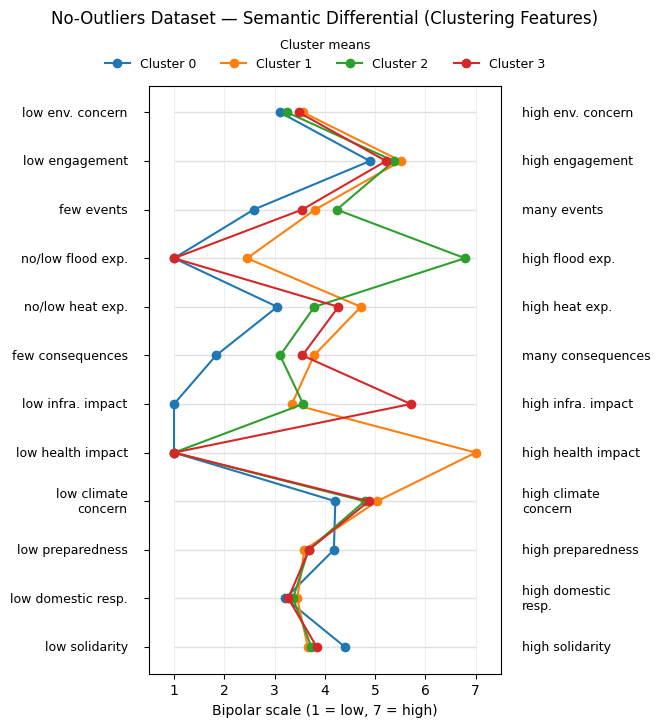

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap
from matplotlib.transforms import blended_transform_factory

# ===== INPUT =====
df = noout12_with_labels.copy()
title = "No-Outliers Dataset — Semantic Differential (Clustering Features)"

poles = {
    "environmental_concerns":        ("low env. concern", "high env. concern"),
    "adaptation_engagement_score":   ("low engagement", "high engagement"),
    "climate_event_count":           ("few events", "many events"),
    "flood_experience":              ("no/low flood exp.", "high flood exp."),
    "heat_experience":               ("no/low heat exp.", "high heat exp."),
    "climate_consequence_count":     ("few consequences", "many consequences"),
    "infra_consequences":            ("low infra. impact", "high infra. impact"),
    "health_consequences":           ("low health impact", "high health impact"),
    "climate_concern":               ("low climate concern", "high climate concern"),
    "personal_preparedness_score":   ("low preparedness", "high preparedness"),
    "domestic_responsibility":       ("low domestic resp.", "high domestic resp."),
    "global_solidarity":             ("low solidarity", "high solidarity"),
}
selected_features = list(poles.keys())

# ===== PREP =====
missing = [f for f in selected_features if f not in df.columns]
if missing:
    raise ValueError(f"Missing in dataframe: {missing}")

means = df.groupby("cluster")[selected_features].mean().T

# keep original values (already MinMax-scaled 0–1), then map to 1–7 for readability
scaled = 1 + 6 * means  # (0–1) → (1–7) linear

ypos = np.arange(len(selected_features))

# ===== PLOT =====
# compact width; height scales with number of items
fig, ax = plt.subplots(figsize=(8, max(7, len(selected_features) * 0.55)))
# extra side space for pole labels
fig.subplots_adjust(left=0.33, right=0.77, top=0.92, bottom=0.08)

# 1–7 rails
for y in ypos:
    ax.hlines(y, xmin=1, xmax=7, color="0.88", linewidth=1)

# cluster lines
for cl in scaled.columns:
    ax.plot(scaled[cl].values, ypos, marker="o", linewidth=1.5, label=f"Cluster {cl}")

# no feature names on Y-axis
ax.set_yticks(ypos)
ax.set_yticklabels([""] * len(ypos))

# compact X-axis
ax.set_xlim(0.5, 7.5)
ax.set_xticks([1, 2, 3, 4, 5, 6, 7])
ax.set_xlabel("Bipolar scale (1 = low, 7 = high)")
ax.set_title(title, pad=45)
ax.grid(axis="x", alpha=0.2)
ax.invert_yaxis()

# place poles OUTSIDE the plotting area, with text wrapping
wrap = lambda s: textwrap.fill(s, width=18)
trans_left  = blended_transform_factory(ax.transAxes, ax.transData)  # x in [0..1], y in data
trans_right = trans_left

for i, feat in enumerate(selected_features):
    left_txt, right_txt = poles[feat]
    ax.text(-0.06, i, wrap(left_txt),  transform=trans_left,
            va="center", ha="right", fontsize=9, clip_on=False)
    ax.text( 1.06, i, wrap(right_txt), transform=trans_right,
            va="center", ha="left",  fontsize=9, clip_on=False)

# horizontal legend below the title (no overlap)
ax.legend(
    title="Cluster means",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10),
    ncol=len(scaled.columns),
    frameon=False,
    fontsize=9,
    title_fontsize=9,
)

plt.show()


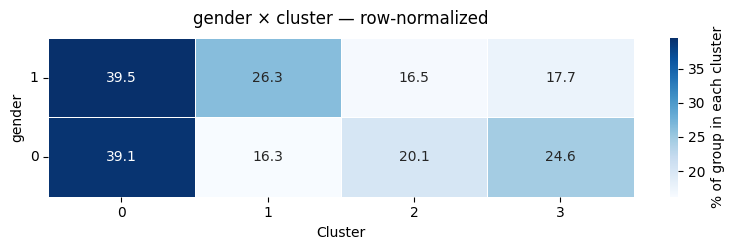

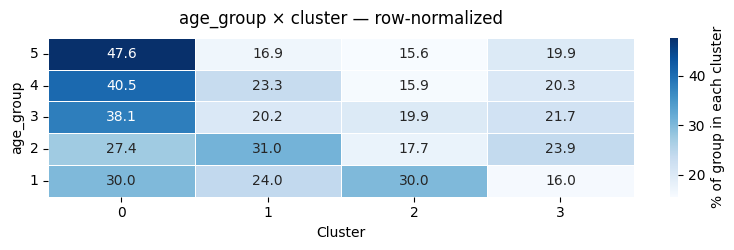

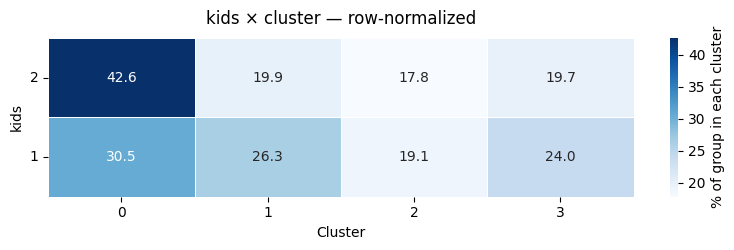

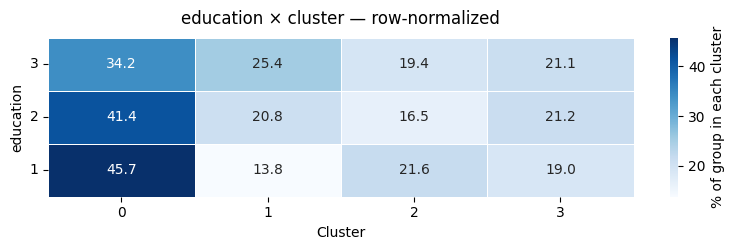

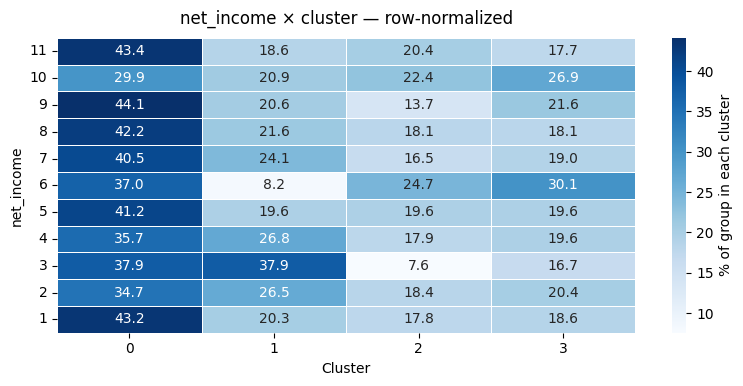

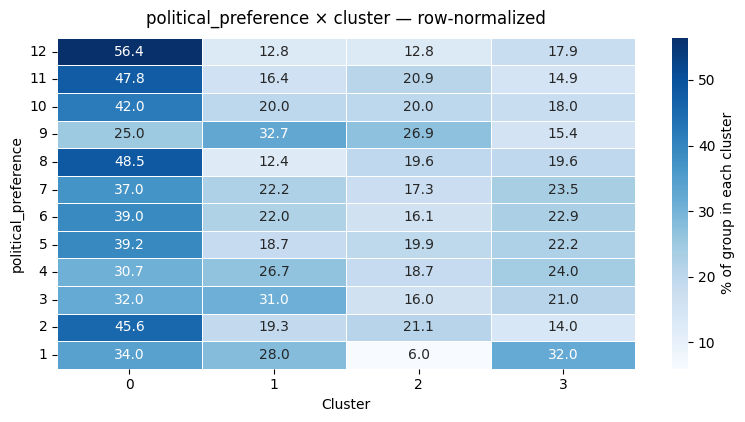

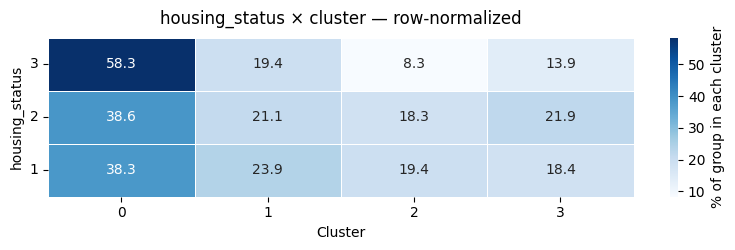

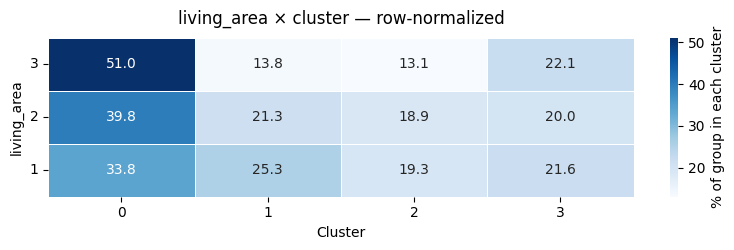

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

# Copy the descriptive dataframe for the no-outliers dataset
dfD = joined_noout["desc"].copy()
cluster_col = "cluster"

# List of categorical/ordinal features to visualize
DESC_FEATS = [
    "gender", "age_group", "kids", "education",
    "net_income", "political_preference", "housing_status", "living_area",
]

# Define the display order for each categorical variable
CATEGORY_ORDERS = {
    "age_group": ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"],
    "education": ["low", "mid", "high", "postgrad"],
    "political_preference": [str(i) for i in range(1, 13)],
    "living_area": ["rural", "town", "suburban", "urban"],
}
NA_LABEL = "Missing"

def _numeric_key(v):
    """Convert value to float if possible, else None (for sorting)."""
    try:
        return float(v)
    except:
        return None

def _row_order_for_display(s: pd.Series, feat: str, bottom_low=True):
    """
    Create the display order for heatmap rows.
    If bottom_low=True, lower values appear at the bottom (e.g., 1 at the bottom).
    """
    s = s.fillna(NA_LABEL).astype(str)
    present = set(s)

    if feat in CATEGORY_ORDERS:
        base = [x for x in CATEGORY_ORDERS[feat] if x in present]
        extra = sorted([x for x in present if x not in base and x != NA_LABEL], key=str.lower)
        asc = base + extra
    else:
        non_na = [x for x in present if x != NA_LABEL]
        nums = [x for x in non_na if _numeric_key(x) is not None]
        if len(nums) >= max(2, len(non_na) - 1):
            asc = sorted(non_na, key=lambda x: _numeric_key(x))
        else:
            asc = sorted(non_na, key=str.lower)

    has_na = NA_LABEL in present
    disp = (list(reversed(asc)) if bottom_low else asc) + ([NA_LABEL] if has_na else [])
    return pd.Categorical(s, categories=disp, ordered=True), disp

def crosstab_row_pct_ordered(df: pd.DataFrame, feat: str, cluster_col: str, bottom_low=True):
    """
    Compute a crosstab and row-normalized percentage table for a feature vs cluster,
    with rows ordered for display.
    """
    a, row_order = _row_order_for_display(df[feat], feat, bottom_low=bottom_low)
    b = df[cluster_col].astype(str)
    ct = pd.crosstab(a, b, dropna=False)
    pct = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0) * 100
    cols = sorted(pct.columns, key=lambda x: (not str(x).isdigit(), int(x) if str(x).isdigit() else str(x)))
    pct = pct.reindex(index=row_order, columns=cols, fill_value=0.0)
    return ct, pct, row_order

def plot_heatmap_bottom_low(df: pd.DataFrame, feat: str, cluster_col: str, bottom_low=True):
    """
    Plot a heatmap showing the row-normalized percentage of each feature level by cluster.
    Lower values are at the bottom if bottom_low=True.
    """
    _, pct, row_order = crosstab_row_pct_ordered(df, feat, cluster_col, bottom_low=bottom_low)
    plt.figure(figsize=(8, max(2.6, 0.36 * len(row_order))))
    ax = sns.heatmap(
        pct, annot=True, fmt=".1f", cmap="Blues",
        linewidths=0.5, linecolor="white",
        cbar_kws={"label": "% of group in each cluster"}
    )
    ax.set_title(f"{feat} × {cluster_col} — row-normalized", pad=10)
    ax.set_xlabel("Cluster")
    ax.set_ylabel(feat)
    ax.set_yticklabels(row_order, rotation=0)
    plt.tight_layout()
    plt.show()

# Build the display order for net_income (works for both numeric and label formats)
_ni = dfD["net_income"].astype(str)
_ni_num = pd.to_numeric(_ni.str.extract(r"^\s*(\d+)")[0], errors="coerce")
order_numeric = (
    pd.DataFrame({"label": _ni, "num": _ni_num})
    .dropna(subset=["num"])
    .drop_duplicates(subset=["label"])
    .sort_values("num")["label"].tolist()
)
# Add any non-numeric labels at the end
extras = sorted([lab for lab in _ni.unique() if lab not in set(order_numeric) and lab != NA_LABEL], key=str.lower)
CATEGORY_ORDERS["net_income"] = order_numeric + extras

# Plot heatmaps for each feature
for feat in DESC_FEATS:
    if feat in dfD.columns:
        plot_heatmap_bottom_low(dfD, feat, cluster_col, bottom_low=True)


## 7. Interpretability ↔ Performance Trade-off

**Goal.** Compare clustering quality in the original feature space vs a reduced space (e.g., PCA/UMAP/t‑SNE),
and estimate *interpretability* by how concentrated feature importance is in the **original** variables.

**Why here?** By this point you have:
- `cluster_df_scaled` (or equivalent): the original numeric features used for clustering.
- One reduced representation (e.g., `cluster_df_pca`, `X_umap`, or `X_tsne`).
- Final cluster labels in a column called `cluster` (e.g., `dfD["cluster"]`).

We won’t re-fit clustering. We only **evaluate** using the existing `cluster` labels.
